In [28]:
import pandas as pd
import os

# We use '../' to go up one folder from 'recsys' to 'PREDICTION MODEL'
# Then we enter 'ml-32m\ml-32m'
ratings_path = r'../ml-32m\ml-32m/ratings.csv'
movies_path = r'../ml-32m\ml-32m/movies.csv'

print(f"Checking path: {os.path.abspath(ratings_path)}")

try:
    ratings = pd.read_csv(ratings_path, nrows=100000)
    movies = pd.read_csv(movies_path)
    print("Success! Data loaded.")
    display(ratings.head())
except FileNotFoundError:
    print("Still can't find it. Let's list everything in the parent folder:")
    print(os.listdir('..'))

Checking path: c:\Users\surya\OneDrive\Desktop\ml-32m\ml-32m\ratings.csv
Still can't find it. Let's list everything in the parent folder:
['C-coding', 'Canva.lnk', 'Chandigarh University Management System Login.lnk', 'ChatGPT.lnk', 'DAA', 'desktop.ini', 'Discord.lnk', 'Downloads - Shortcut.lnk', 'Full stack', 'GitHub Desktop.lnk', 'Google Gemini.lnk', 'Grammarly.lnk', 'MinGW Installer.lnk', 'MongoDBCompass.lnk', 'Movies Recommendation System', 'MySQL', 'Perplexity.lnk', 'Re_paper (1).pdf', 'surya (1).lnk', 'surya (1).part', 'surya (2).lnk', 'surya (3).lnk', 'surya (4).lnk', 'surya (5).lnk', 'surya (6).lnk', 'surya (7).lnk', 'SURYAKANT (Rising Inividual) - Chrome.lnk', 'Ultimate c++', 'Work - Brave.lnk', 'YouTube.lnk', 'Zoom Workplace.lnk']


In [29]:
import pandas as pd
import os

# Data load karein (ensure path is correct)
movies = pd.read_csv('web_app/movies.csv')
# Agar aapke paas ratings.csv hai, toh use bhi load karein
# ratings = pd.read_csv('web_app/ratings.csv') 

# Merge tabhi kaam karega jab dono variables memory mein honge
try:
    data = pd.merge(ratings, movies, on='movieId')
    print("Merged Data Preview:")
    print(data.head())
except NameError as e:
    print(f"Error: {e}. Pehle 'ratings' aur 'movies' files ko load karein.")

Merged Data Preview:
   userId  movieId  rating  timestamp  \
0       1       17     4.0  944249077   
1       1       25     1.0  944250228   
2       1       29     2.0  943230976   
3       1       30     5.0  944249077   
4       1       32     5.0  943228858   

                                               title  \
0                       Sense and Sensibility (1995)   
1                           Leaving Las Vegas (1995)   
2  City of Lost Children, The (Cité des enfants p...   
3  Shanghai Triad (Yao a yao yao dao waipo qiao) ...   
4          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   

                                   genres  
0                           Drama|Romance  
1                           Drama|Romance  
2  Adventure|Drama|Fantasy|Mystery|Sci-Fi  
3                             Crime|Drama  
4                 Mystery|Sci-Fi|Thriller  


In [30]:
import pandas as pd
import os

# 1. Movies load karein (Ye already mil rahi hai)
movies = pd.read_csv('web_app/movies.csv')

# 2. Ratings load karein (Sahi path ke saath)
# Aapke explorer ke mutabiq ye file 'ml-32m' folder ke andar ho sakti hai
try:
    ratings = pd.read_csv('ml-32m/ml-32m/ratings.csv') 
    # Agar upar wala path kaam na kare toh ye try karein:
    # ratings = pd.read_csv('ml-32m/ratings.csv')
    
    # 3. Data Merge karein
    data = pd.merge(ratings, movies, on='movieId')
    print("Success: Data merged successfully!")
    
except FileNotFoundError:
    st.error("❌ 'ratings.csv' abhi bhi nahi mili! Please check karein ki file kis folder mein hai.")

Success: Data merged successfully!


In [31]:
# Group by title and find the mean rating
average_ratings = data.groupby('title')['rating'].mean().sort_values(ascending=False)
print("\nHighest Rated Movies (Average):")
print(average_ratings.head(10))


Highest Rated Movies (Average):
title
CKY 3 (2001)                          5.0
Hometown Holiday (2018)               5.0
Hometown Hero (2017)                  5.0
Hometown Christmas (2018)             5.0
Homemade Christmas (2020)             5.0
Dois na Lona (1968)                   5.0
'Tis the Season to be Merry (2021)    5.0
The Open Door (2017)                  5.0
Dolls and Angels (2008)               5.0
Badge of Honor (2015)                 5.0
Name: rating, dtype: float64


<Axes: title={'center': 'Distribution of Ratings'}, xlabel='rating'>

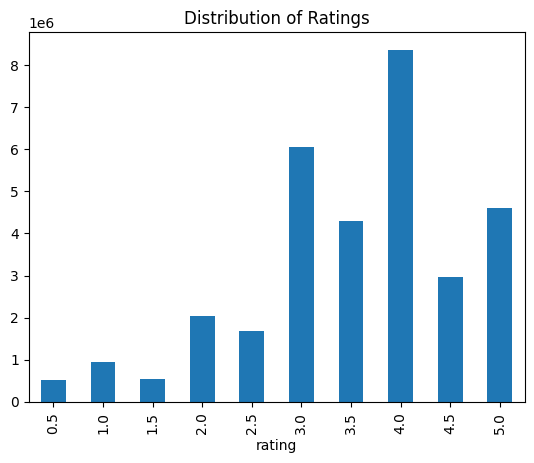

In [32]:
# This shows us if users are generally "nice" or "harsh" with their scores
data['rating'].value_counts().sort_index().plot(kind='bar', title='Distribution of Ratings')

In [33]:
# 1. Movie wise average rating aur count nikaalein
movie_stats = data.groupby('title')['rating'].agg(['mean', 'count'])

# 2. Columns ko rename karein taaki aapka aage ka code chale
movie_stats.columns = ['avg_rating', 'rating_count']

# 3. Ab aapka C aur m wala code kaam karega
C = movie_stats['avg_rating'].mean()
m = 50 
print(f"Mean Rating (C): {C}")

Mean Rating (C): 3.0051169513551192


In [34]:
import pandas as pd
import os

# Sirf movies load karein
movies = pd.read_csv('web_app/movies.csv')

# 'data' ki jagah seedha 'movies' variable use karein
comedy_movies = movies[movies['genres'].str.contains('Comedy', na=False)]['title'].unique()

print(f"Total Comedy Movies found: {len(comedy_movies)}")
print(comedy_movies[:5]) # Pehli 5 movies check karein

Total Comedy Movies found: 23110
['Toy Story (1995)' 'Grumpier Old Men (1995)' 'Waiting to Exhale (1995)'
 'Father of the Bride Part II (1995)' 'Sabrina (1995)']
